# A Gentle Introduction to Solving ODEs in Python

This notebook gives a practical introduction to numerically solving initial value problems (IVPs):
$ y'(t) = f(t, y), \quad y(t_0) = y_0.$

Syllabus:
1. How to step an ODE with **Euler**, **RK2 (midpoint)**, and **RK4**.
2. How to use **SciPy**'s `solve_ivp` for adaptive step-size integration.
3. How to solve **systems** of ODEs.
4. How to set **tolerances** and use **events** to stop on conditions.
5. Exercises.



## 0) Test problem and exact solution (for error checks)
We'll use a smooth scalar ODE with a known solution:  
$ y'(t) = y - t^2 + 1, \quad y(0)=0.5.$  
Exact solution:  
$y(t) = (t+1)^2 - \tfrac{1}{2}e^{t}. $  
Compare our numerical methods against this to see errors.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y - t**2 + 1.0

def y_exact(t):
    return (t + 1.0)**2 - 0.5*np.exp(t)

t0, y0 = 0.0, 0.5
T = 2.0  # final time for demos
print("y(0) exact =", y_exact(0.0))

y(0) exact = 0.5


## 1) Stepping methods from scratch: Euler, RK2, RK4
The basic idea is to move from $t_n$ to $t_{n+1}=t_n+h$ using a slope estimate.

- **Euler:** $y_{n+1} = y_n + h f(t_n, y_n)$ (order 1)  
- **RK2 (midpoint):** $k_1=f(t_n,y_n),\;k_2=f(t_n+\tfrac{h}{2}, y_n+\tfrac{h}{2}k_1),\; y_{n+1}=y_n + h k_2$ (order 2)
- **RK4:** classical 4-stage (order 4)

Implement these and compare on the test problem.

![Euler_RK2_midpoints_no_field.png](Euler_RK2_midpoints_no_field.png)

![ode_1.png](ode_1.png)

![ode_2.png](ode_2.png)

![Euler_RK2_midpoints_no_field.png](Euler_RK2_midpoints_no_field.png)

![ode_3.png](ode_3.png)

![ode_4.png](ode_4.png)

![ode_5.png](ode_5.png)

![RK4_final_star_navy_t.png](RK4_final_star_navy_t.png)

![ode_6.png](ode_6.png)

In [2]:
def euler(f, t0, y0, h, n):
    ts = np.empty(n+1); ys = np.empty(n+1)
    ts[0], ys[0] = t0, y0
    t, y = t0, y0
    for k in range(n):
        y = y + h * f(t, y)
        t = t + h
        ts[k+1], ys[k+1] = t, y
    return ts, ys

def rk2_midpoint(f, t0, y0, h, n):
    ts = np.empty(n+1); ys = np.empty(n+1)
    ts[0], ys[0] = t0, y0
    t, y = t0, y0
    for k in range(n):
        k1 = f(t, y)
        tm = t + 0.5*h
        ym = y + 0.5*h*k1
        k2 = f(tm, ym)
        y = y + h*k2
        t = t + h
        ts[k+1], ys[k+1] = t, y
    return ts, ys

def rk4(f, t0, y0, h, n):
    ts = np.empty(n+1); ys = np.empty(n+1)
    ts[0], ys[0] = t0, y0
    t, y = t0, y0
    for k in range(n):
        k1 = f(t, y)
        k2 = f(t + 0.5*h, y + 0.5*h*k1)
        k3 = f(t + 0.5*h, y + 0.5*h*k2)
        k4 = f(t + h,     y + h*k3)
        y = y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        t = t + h
        ts[k+1], ys[k+1] = t, y
    return ts, ys

### Compare methods on the same step size

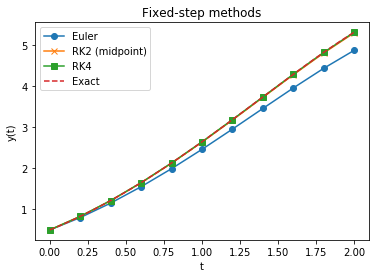

In [3]:
h = 0.2
N = int((T - t0)/h)
te, ye = euler(f, t0, y0, h, N)
tr2, yr2 = rk2_midpoint(f, t0, y0, h, N)
tr4, yr4 = rk4(f, t0, y0, h, N)

tt = np.linspace(t0, T, 400)
ye_exact = y_exact(tt)

plt.figure()
plt.plot(te, ye, marker='o', linestyle='-', label='Euler')
plt.plot(tr2, yr2, marker='x', linestyle='-', label='RK2 (midpoint)')
plt.plot(tr4, yr4, marker='s', linestyle='-', label='RK4')
plt.plot(tt, ye_exact, linestyle='--', label='Exact')
plt.xlabel('t'); plt.ylabel('y(t)'); plt.title('Fixed-step methods')
plt.legend(); plt.show()

### Convergence check (global error vs step size)

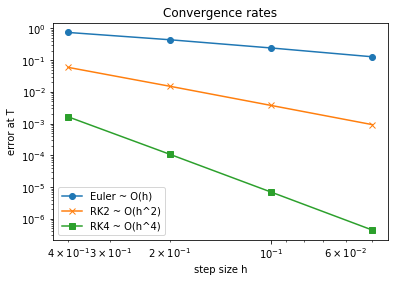

In [10]:
hs = np.array([0.4, 0.2, 0.1, 0.05])
errs_e, errs_r2, errs_r4 = [], [], []
yT = y_exact(T)
for h in hs:
    N = int(round((T - t0)/h))
    te, ye = euler(f, t0, y0, h, N)
    tr2, yr2 = rk2_midpoint(f, t0, y0, h, N)
    tr4, yr4 = rk4(f, t0, y0, h, N)
    errs_e.append(abs(ye[-1]  - yT))
    errs_r2.append(abs(yr2[-1] - yT))
    errs_r4.append(abs(yr4[-1] - yT))

plt.figure()
plt.loglog(hs, errs_e, marker='o', label='Euler ~ O(h)')
plt.loglog(hs, errs_r2, marker='x', label='RK2 ~ O(h^2)')
plt.loglog(hs, errs_r4, marker='s', label='RK4 ~ O(h^4)')
plt.gca().invert_xaxis()
plt.xlabel('step size h')
plt.ylabel('error at T')
plt.title('Convergence rates')
plt.legend(); plt.show()

## 2) Adaptive integration with SciPy: `solve_ivp`

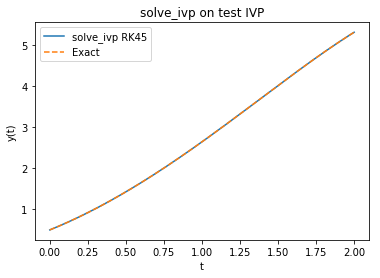

Status: 0 | nfev: 50


In [5]:
try:
    from scipy.integrate import solve_ivp
    t_eval = np.linspace(t0, T, 200)
    sol = solve_ivp(f, (t0, T), [y0], t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-9)
    plt.figure()
    plt.plot(sol.t, sol.y[0], label='solve_ivp RK45')
    plt.plot(t_eval, y_exact(t_eval), linestyle='--', label='Exact')
    plt.xlabel('t');
    plt.ylabel('y(t)')
    plt.title('solve_ivp on test IVP')
    plt.legend()
    plt.show()
    print('Status:', sol.status, '| nfev:', sol.nfev)
except Exception as e:
    print('SciPy not available or failed:', e)

## 3) Systems of ODEs: harmonic oscillator

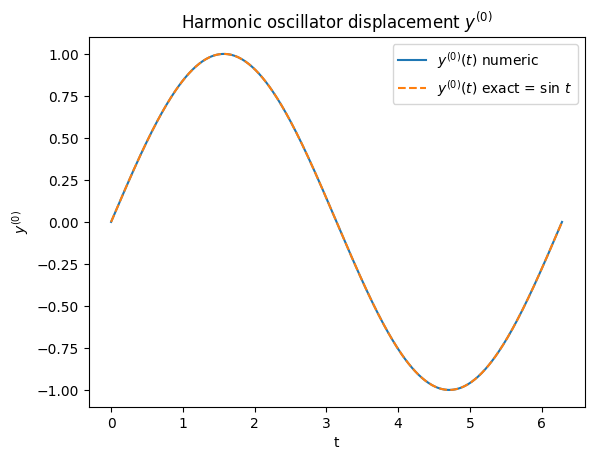

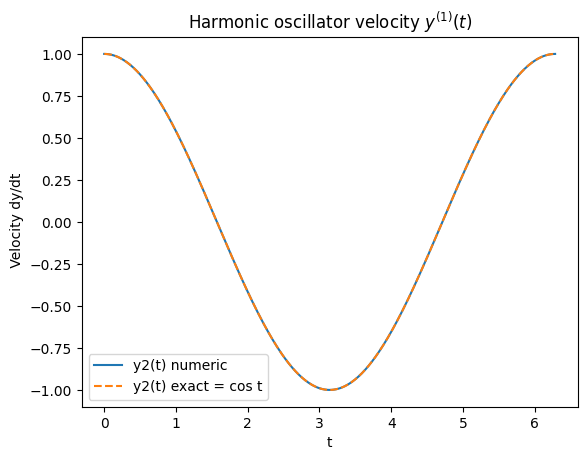

In [36]:
try:
    def sho(t, Y):
        y_0, y_0_dot = Y
        return [y_0_dot, -y_0]


    t_eval = np.linspace(0, 2*np.pi, 400)
    sol = solve_ivp(sho, (0, 2*np.pi), [0.0, 1.0], t_eval=t_eval, rtol=1e-9, atol=1e-12)
    plt.figure()
    plt.plot(sol.t, sol.y[0], label='$y^{(0)}(t)$ numeric')
    plt.plot(sol.t, np.sin(sol.t), linestyle='--', label='$y^{(0)}(t)$ exact = $\sin\,t$')
    plt.xlabel('t')
    plt.ylabel('$y^{(0)}$')
    plt.title('Harmonic oscillator displacement $y^{(0)}$')
    plt.legend(); plt.show()

    plt.figure()
    plt.plot(sol.t, sol.y[1], label='y2(t) numeric')
    plt.plot(sol.t, np.cos(sol.t), linestyle='--', label='y2(t) exact = cos t')
    plt.xlabel('t')
    plt.ylabel(' Velocity dy/dt')
    plt.title('Harmonic oscillator velocity $y^{(1)}(t)$')
    plt.legend(); plt.show()
except Exception as e:
    print('SciPy not available or failed:', e)

## 4) Events: stop when a condition is met

In [ ]:
try:
    def event_y_hits_1p5(t, y):
        return y[0] - 1.5
    event_y_hits_1p5.terminal = True
    event_y_hits_1p5.direction = 0

    sol = solve_ivp(f, (t0, 5.0), [y0], events=event_y_hits_1p5, rtol=1e-7, atol=1e-10)
    t_hit = sol.t_events[0][0]
    y_hit = sol.y_events[0][0,0]
    t_dense = np.linspace(t0, t_hit, 400)
    plt.figure()
    plt.plot(t_dense, y_exact(t_dense), linestyle='--', label='Exact')
    plt.plot(sol.t, sol.y[0], marker='o', label='solve_ivp')
    plt.axhline(1.5, linestyle=':')
    plt.axvline(t_hit, linestyle=':')
    plt.xlabel('t'); plt.ylabel('y(t)'); plt.title('Event: stop when y(t)=1.5')
    plt.legend(); plt.show()
    print(f'Stopped at t ~ {t_hit:.6f}, y ~ {y_hit:.6f}')
except Exception as e:
    print('SciPy not available or failed:', e)

Stopped at t ~ 0.533871, y ~ 1.500000


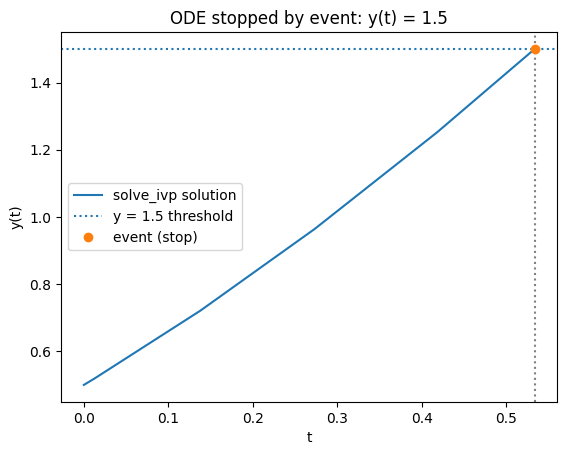

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE: y' = y - t^2 + 1,  y(0)=0.5
def f(t, y):
    return y - t**2 + 1.0

# Event: stop when y(t) = 1.5  (i.e., g(t,y)=y-1.5 hits 0)
def event_y_hits_1p5(t, y):
    return y[0] - 1.5
event_y_hits_1p5.terminal = True   # stop integration at the event
event_y_hits_1p5.direction = 0     # detect both upward and downward crossings

t0, tf = 0.0, 5.0
y0 = [0.5]

sol = solve_ivp(f, (t0, tf), y0, events=event_y_hits_1p5, rtol=1e-7, atol=1e-10)

# Extract event time/state
t_hit = sol.t_events[0][0]
y_hit = sol.y_events[0][0, 0]
print(f"Stopped at t ~ {t_hit:.6f}, y ~ {y_hit:.6f}")

# Plot solution up to the stop time and mark the event
plt.figure()
plt.plot(sol.t, sol.y[0], label='solve_ivp solution')
plt.axhline(1.5, linestyle=':', label='y = 1.5 threshold')
plt.axvline(t_hit, linestyle=':', color='gray')
plt.plot([t_hit], [y_hit], 'o', label='event (stop)')
plt.xlabel('t'); plt.ylabel('y(t)')
plt.title('ODE stopped by event: y(t) = 1.5')
plt.legend()
plt.show()


$\simeq$

## 5) Solve 1st order ODE

$$
dy/dt = cos\,\omega t
$$

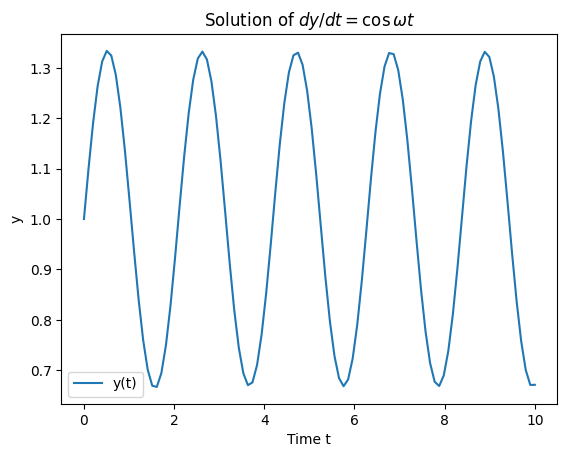

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE
def dydt(t, y, param1):
    return  np.cos(param1*t)

# Time span and initial condition
t_span = (0, 10)  # from t=0 to t=10
N= 100            # number of time values, used in solve_ivp
ps = (3.,)        # tuple that contains angular frequency value
y0 = [1]         # initial condition y(0) = 

# Solve the ODE. Note that args uses the tuple that contains the angular frequency.
# Note also the star * notation used in linspace.
solution = solve_ivp(dydt, t_span, y0, method='RK45', t_eval=np.linspace(*t_span, N), args=ps)

# Note: solution.t and y[0] are numpy arrays

# Plot the solution
plt.plot(solution.t, solution.y[0], label='y(t)')
plt.title(r"Solution of $dy/dt = \cos\omega t $")
plt.xlabel("Time t")
plt.ylabel("y")
plt.legend()
plt.show()


## 6) Solve a pair of coupled diffeqs

In [ ]:
'''
Solves a pair of coupled 2nd order diffeqs.
d/dt(xdot) = -ax + by
d/dt(ydot) - -cy + dx
a,b,c,d = consts

Can be simplified by making subs: xdot = u and ydot = v
Then we have:

xdot = u
udot = -ax + by
ydot = v
vdot = -cy + dx
'''

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# First things first.
# Define the system of first-order equations.
def coupled_second_order(t, z, a, b, c, d):
    x, u, y, v = z  # z[0] = x, z[1] = u (dx/dt), z[2] = y, z[3] = v (dy/dt)
    dxdt = u
    dudt = -a * x + b * y
    dydt = v
    dvdt = -c * y + d * x
    return [dxdt, dudt, dydt, dvdt]

# Parameters
a, b, c, d = 2.0, 1.0, 2.0, 1.0  # Constants
initial_conditions = [1.0, 0.0, 0.0, 1.0]  # Initial [x, dx/dt (u), y, dy/dt (v)]
t_span = (0, 20)  # Time range for the solution
t_eval = np.linspace(t_span[0], t_span[1], 5000)  # Points where we want the solution

# t_span = (0, 200)  # Time range for the solution
# t_eval = np.linspace(t_span[0], t_span[1], 50000)  # Points where we want the solution


# Solve the system
solution = solve_ivp(
    coupled_second_order,
    t_span,
    initial_conditions,
    t_eval=t_eval,
    args=(a, b, c, d),
    method="RK45"
)

# Extract results
t = solution.t
x = solution.y[0]  # x(t)
xdot = solution.y[1] # xdot(t)
y = solution.y[2]  # y(t)

# Plot the results
plt.figure(figsize=(12, 6))

# Plot x(t) and y(t)
plt.subplot(1, 2, 1)
plt.plot(t, x, label="x(t)", color="blue")
plt.plot(t, y, label="y(t)", color="green")
plt.title("Displacement vs. Time")
plt.xlabel("Time (t)")
plt.ylabel("Displacement")
plt.legend()
plt.grid()

# Plot phase space (x vs. y)
plt.subplot(1, 2, 2)
plt.plot(x, xdot, label=r'$\dot{x}$ v. x', color="red")
# plt.plot(x, y, label="\'Phase Space\'", color="red")
# plt.title("\'Phase Space\' (y vs. x)")
plt.title(r'$V_x$ v. x ')
plt.xlabel("x")
plt.ylabel(r'$V_x$')
#plt.ylabel("y")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


## 7) Another pair of coupled diffeqs

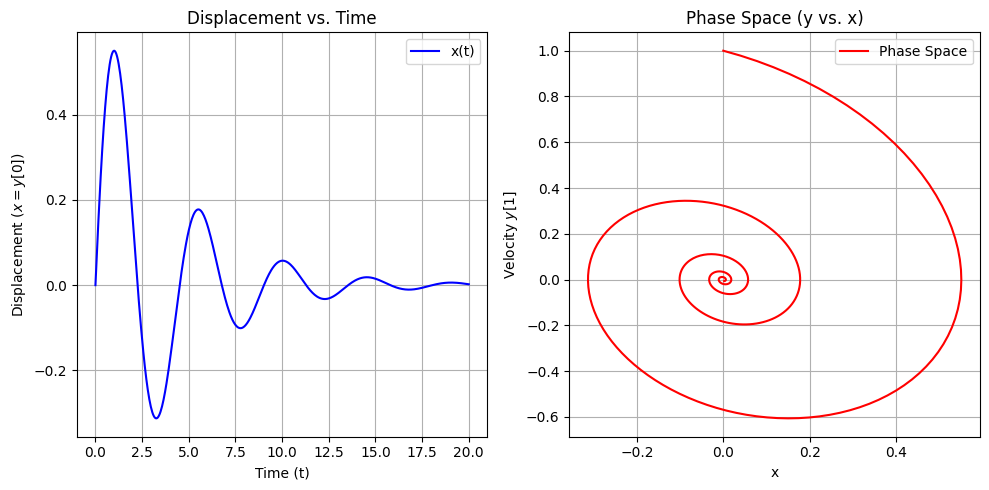

In [15]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the system of differential equations
def coupled_equations(t, z, k, c):
    x, y = z  # z is a vector where z[0] = x and z[1] = y
    dxdt = y
    dydt = -k * x - c * y
    return [dxdt, dydt]

# Parameters
k = 2.0  # Spring constant
c = 0.5  # Damping coefficient
initial_conditions = [0.0, 1.0]  # Initial displacement and velocity
t_span = (0, 20)  # Time range for the solution
t_eval = np.linspace(t_span[0], t_span[1], 500)  # Points where we want the solution

# Solve the system of equations
solution = solve_ivp(
    coupled_equations,
    t_span,
    initial_conditions,
    t_eval=t_eval,
    args=(k, c),
    method="RK45"
)


# Extract results
t = solution.t
x = solution.y[0]  # x(t)
y = solution.y[1]  # y(t)

# Plot the results
plt.figure(figsize=(10, 5))

# Plot x(t)
plt.subplot(1, 2, 1)
plt.plot(t, x, label="x(t)", color="blue")
plt.title("Displacement vs. Time")
plt.xlabel("Time (t)")
plt.ylabel("Displacement $(x = y[0])$")
plt.grid()
plt.legend()

# Plot phase space (x vs. y)
plt.subplot(1, 2, 2)
plt.plot(x, y, label="Phase Space", color="red")
plt.title("Phase Space (y vs. x)")
plt.xlabel("x")
plt.ylabel("Velocity $y[1]$")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


---
---

### Exercises

**1.**  Solve:
$$
\frac{d^2x}{dt^2} = -\omega^2x^3
$$

Take $\omega=1$ and initial conditions $x=1$ and $dx/dt=0$.   
Plot the motion of the oscillator, $dx/dt$ versus $x$.

**2.**  A real (simple) pendulum satisfies:
$$
\frac{d^2\theta}{dt^2} + (l/g)\sin\theta = 0,
$$

where $\theta$ is the angle with respect to the vertical and $l$ is the pendulum length. Take $l=1$ and initial condition $\theta_0=\pi/4$ radians. Let the pendulum start from rest. Plot the angular displacement of the pendulum $\theta(t)$ in one plot and its linear velocity, $l\dot{\theta}$ versus $\theta$ in another.